# GSE44076: Gene-Collapse Sensitivity Check

This notebook checks how sensitive the first gene-level summary is to probe-to-gene collapse choices. It examines probe multiplicity, direction agreement among probes assigned to the same gene symbol, and overlap between two representative-probe rules.

This is a methodological sensitivity check. It does not establish gene-level differential expression, identify biomarkers, support pathway interpretation, or provide clinical or mechanistic conclusions.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import (  # noqa: E402
    build_paired_sample_table,
    derive_pair_ids,
    paired_ttest_by_probe,
)
from src.annotation import (  # noqa: E402
    annotate_probe_ranking,
    collapse_by_largest_abs_effect,
    collapse_to_gene_level,
    compare_gene_collapse_rules,
    load_gpl_annotation,
    summarize_gene_probe_consistency,
)
from src.geo_loader import (  # noqa: E402
    align_expression_with_metadata,
    build_sample_metadata_table,
    convert_expression_to_numeric,
    load_geo_expression_table,
    read_geo_series_lines,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE44076_series_matrix.txt.gz"
ANNOTATION_PATH = PROJECT_ROOT / "data" / "raw" / "GPL13667.annot.gz"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "sample_metadata.csv"
PAIRED_RANKING_PATH = PROJECT_ROOT / "data" / "processed" / "tumor_vs_paired_normal_paired_probe_ranking.csv"
ANNOTATED_RANKING_PATH = PROJECT_ROOT / "data" / "processed" / "tumor_vs_paired_normal_paired_probe_ranking_annotated.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GROUP_MAP = {
    "Healthy colon mucosa cells": "healthy_mucosa",
    "Normal distant colon mucosa cells": "paired_normal_mucosa",
    "Primary colon adenocarcinoma cells": "tumor",
}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Load or Rebuild the Annotated Paired Ranking

The local annotated paired ranking is used when available. If absent, it is rebuilt from the local series matrix, sample metadata, paired comparison, and GPL13667 annotation.

In [2]:
if ANNOTATED_RANKING_PATH.is_file():
    annotated_ranking = pd.read_csv(ANNOTATED_RANKING_PATH)
    ranking_source = ANNOTATED_RANKING_PATH.relative_to(PROJECT_ROOT)
else:
    if not RAW_PATH.is_file() or not ANNOTATION_PATH.is_file():
        raise FileNotFoundError(
            "Rebuilding requires the local GSE44076 series matrix and GPL13667 annotation."
        )

    expression = load_geo_expression_table(RAW_PATH)
    if METADATA_PATH.is_file():
        sample_metadata = pd.read_csv(METADATA_PATH)
    else:
        sample_metadata = build_sample_metadata_table(read_geo_series_lines(RAW_PATH))
        sample_metadata["group"] = sample_metadata["source_name"].map(GROUP_MAP)

    expression, sample_metadata = align_expression_with_metadata(expression, sample_metadata)
    expression = convert_expression_to_numeric(expression)
    paired_metadata = derive_pair_ids(sample_metadata)
    paired_metadata = paired_metadata[
        paired_metadata["group"].isin(["tumor", "paired_normal_mucosa"])
    ]
    pair_table = build_paired_sample_table(paired_metadata, "group", "pair_id")

    if PAIRED_RANKING_PATH.is_file():
        paired_ranking = pd.read_csv(PAIRED_RANKING_PATH)
    else:
        paired_ranking = paired_ttest_by_probe(
            expression,
            pair_table,
            tumor_column="tumor",
            normal_column="paired_normal_mucosa",
        )
        PAIRED_RANKING_PATH.parent.mkdir(parents=True, exist_ok=True)
        paired_ranking.to_csv(PAIRED_RANKING_PATH, index=False)

    platform_annotation = load_gpl_annotation(ANNOTATION_PATH)
    annotated_ranking = annotate_probe_ranking(paired_ranking, platform_annotation)
    annotated_ranking.to_csv(ANNOTATED_RANKING_PATH, index=False)
    ranking_source = "rebuilt from local raw and processed inputs"

print(f"Annotated ranking source: {ranking_source}")
print(f"Probe rows: {len(annotated_ranking):,}")
print(f"Rows with gene symbol: {annotated_ranking['gene_symbol'].notna().sum():,}")

Annotated ranking source: data\processed\tumor_vs_paired_normal_paired_probe_ranking_annotated.csv
Probe rows: 49,386
Rows with gene symbol: 48,784


## Probe Multiplicity and Direction Consistency

Multi-symbol annotation cells are expanded. Within each gene symbol, direction conflict means at least one mapped probe has a positive paired difference and another has a negative paired difference. Exact zero differences are counted separately and do not create a conflict by themselves.

In [3]:
consistency = summarize_gene_probe_consistency(annotated_ranking)
multi_probe_consistency = consistency[consistency["probe_count"] > 1].copy()

all_consistent_count = int(consistency["same_direction"].sum())
multi_consistent_count = int(multi_probe_consistency["same_direction"].sum())
multi_conflict_count = int(multi_probe_consistency["direction_conflict"].sum())

print(f"Gene symbols checked: {len(consistency):,}")
print(f"Single-probe genes: {(consistency['probe_count'] == 1).sum():,}")
print(f"Multi-probe genes: {len(multi_probe_consistency):,}")
print(
    f"All genes without positive-negative conflict: {all_consistent_count:,} "
    f"({all_consistent_count / len(consistency):.1%})"
)
print(
    f"Multi-probe genes without conflict: {multi_consistent_count:,} "
    f"({multi_consistent_count / len(multi_probe_consistency):.1%})"
)
print(
    f"Multi-probe genes with conflicting directions: {multi_conflict_count:,} "
    f"({multi_conflict_count / len(multi_probe_consistency):.1%})"
)
display(consistency.head(15))

Gene symbols checked: 20,217
Single-probe genes: 6,977
Multi-probe genes: 13,240
All genes without positive-negative conflict: 15,908 (78.7%)
Multi-probe genes without conflict: 8,931 (67.5%)
Multi-probe genes with conflicting directions: 4,309 (32.5%)


,gene_symbol,probe_count,positive_probe_count,negative_probe_count,zero_probe_count,direction_conflict,same_direction
0,NF1,21,18,3,0,True,False
1,RHD,19,10,9,0,True,False
2,TRD@,19,4,15,0,True,False
3,IGHM,18,8,10,0,True,False
4,FOXP1,17,0,17,0,False,True
5,DMKN,16,12,4,0,True,False
6,FMNL1,16,8,8,0,True,False
7,IGKC,16,1,15,0,True,False
8,NFATC4,16,1,15,0,True,False
9,ABI1,15,0,15,0,False,True


## Genes with Many Probes and Conflicting Directions

In [4]:
expanded = annotated_ranking.dropna(subset=["gene_symbol"]).copy()
expanded["gene_symbol"] = expanded["gene_symbol"].str.split(r"\s*///\s*")
expanded = expanded.explode("gene_symbol")
expanded["gene_symbol"] = expanded["gene_symbol"].str.strip()

effect_ranges = (
    expanded.groupby("gene_symbol")["mean_paired_difference"]
    .agg(minimum_effect="min", maximum_effect="max")
    .reset_index()
)
conflict_examples = (
    multi_probe_consistency[multi_probe_consistency["direction_conflict"]]
    .merge(effect_ranges, on="gene_symbol", how="left")
    .sort_values(["probe_count", "gene_symbol"], ascending=[False, True])
)
display(conflict_examples.head(20))

,gene_symbol,probe_count,positive_probe_count,negative_probe_count,zero_probe_count,direction_conflict,same_direction,minimum_effect,maximum_effect
0,NF1,21,18,3,0,True,False,-0.245389,0.500956
1,RHD,19,10,9,0,True,False,-0.093047,0.164617
2,TRD@,19,4,15,0,True,False,-1.485384,0.068138
3,IGHM,18,8,10,0,True,False,-1.930152,1.216317
4,DMKN,16,12,4,0,True,False,-0.059822,1.399208
5,FMNL1,16,8,8,0,True,False,-0.119474,0.094849
6,IGKC,16,1,15,0,True,False,-1.814185,0.099147
7,NFATC4,16,1,15,0,True,False,-0.395702,0.029791
8,BCL2L11,14,2,12,0,True,False,-0.772581,0.072741
9,IGHG1,14,7,7,0,True,False,-0.091421,1.216317


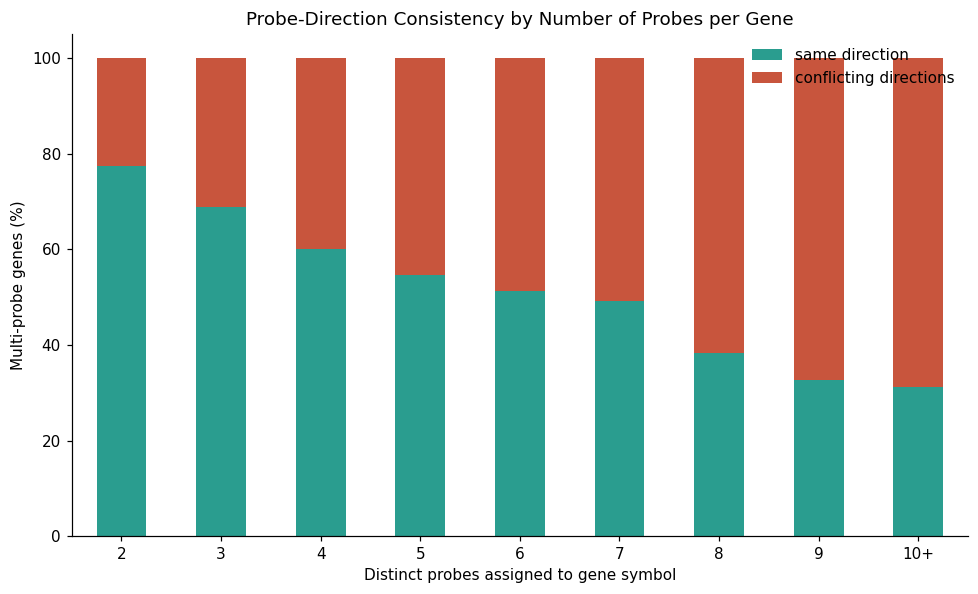

In [5]:
plot_consistency = multi_probe_consistency.copy()
plot_consistency["probe_count_group"] = plot_consistency["probe_count"].clip(upper=10)
direction_counts = (
    plot_consistency.groupby(["probe_count_group", "direction_conflict"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "same direction", True: "conflicting directions"})
)
direction_percent = direction_counts.div(direction_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
direction_percent.plot(
    kind="bar",
    stacked=True,
    color=["#2A9D8F", "#C8553D"],
    ax=ax,
)
labels = [str(value) if value < 10 else "10+" for value in direction_percent.index]
ax.set_xticklabels(labels, rotation=0)
ax.set_title("Probe-Direction Consistency by Number of Probes per Gene")
ax.set_xlabel("Distinct probes assigned to gene symbol")
ax.set_ylabel("Multi-probe genes (%)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gene_probe_direction_consistency.png", dpi=180, bbox_inches="tight")
plt.show()

## Compare Two Representative-Probe Rules

Rule A keeps the probe with the smallest adjusted p-value for each gene. Rule B keeps the probe with the largest absolute paired mean difference. Both retain one probe per expanded gene symbol, but they optimize different quantities.

In [6]:
smallest_p_table = collapse_to_gene_level(annotated_ranking)
largest_effect_table = collapse_by_largest_abs_effect(annotated_ranking)

representative_comparison = smallest_p_table[["gene_symbol", "probe_id"]].merge(
    largest_effect_table[["gene_symbol", "probe_id"]],
    on="gene_symbol",
    suffixes=("_smallest_p", "_largest_effect"),
    validate="one_to_one",
)
same_representative_count = int(
    (
        representative_comparison["probe_id_smallest_p"]
        == representative_comparison["probe_id_largest_effect"]
    ).sum()
)

print(f"Rule A gene rows: {len(smallest_p_table):,}")
print(f"Rule B gene rows: {len(largest_effect_table):,}")
print(
    "Genes selecting the same representative probe under both rules: "
    f"{same_representative_count:,}"
)

display(
    smallest_p_table[
        ["gene_symbol", "probe_id", "probe_count", "mean_paired_difference", "adjusted_p_value"]
    ].head(10)
)
display(
    largest_effect_table[
        ["gene_symbol", "probe_id", "probe_count", "mean_paired_difference", "adjusted_p_value"]
    ].head(10)
)

Rule A gene rows: 20,217
Rule B gene rows: 20,217
Genes selecting the same representative probe under both rules: 17,464


,gene_symbol,probe_id,probe_count,mean_paired_difference,adjusted_p_value
0,CLDN1,11728232_a_at,4,4.920208,5.145358e-59
1,KIAA1199,11735833_a_at,2,4.699381,2.508659e-58
2,ETV4,11719434_a_at,2,3.297047,8.376406e-56
3,SLC6A6,11721993_at,5,3.303735,8.495091e-56
4,CA7,11733581_a_at,1,-4.651000,5.584336e-55
5,CDH3,11739128_a_at,2,3.592385,6.954774e-55
6,OTOP2,11759464_at,2,-5.157509,5.053490e-54
7,GUCA2B,11732838_at,1,-6.547316,2.533048e-53
8,ABCA8,11721557_a_at,5,-4.280251,2.923551e-52
9,GTF2IRD1,11750604_a_at,1,2.372823,2.923551e-52


,gene_symbol,probe_id,probe_count,mean_paired_difference,adjusted_p_value
0,CA1,11729583_x_at,3,-7.717337,7.322387e-45
1,CLCA4,11728771_a_at,2,-7.269623,1.024773e-38
2,TMIGD1,11737294_a_at,1,-6.928715,1.078155e-49
3,AQP8,11726764_at,1,-6.616658,2.401850e-51
4,MS4A12,11733744_at,1,-6.607507,4.222565e-40
5,GUCA2B,11732838_at,1,-6.547316,2.533048e-53
6,ZG16,11722059_at,2,-6.378634,9.366977e-34
7,CA4,11730973_a_at,1,-6.211607,3.076556e-40
8,GUCA2A,11731957_at,1,-6.047716,1.001690e-43
9,ADH1B,11722995_at,6,-5.809252,7.081684e-46


## Top-Gene Overlap

In [7]:
top_sizes = [10, 20, 50, 100]
overlap_rows = []
for top_n in top_sizes:
    comparison = compare_gene_collapse_rules(
        smallest_p_table,
        largest_effect_table,
        top_n=top_n,
    )
    overlap_count = int(comparison["in_both"].sum())
    overlap_rows.append(
        {
            "top_n": top_n,
            "overlap_count": overlap_count,
            "overlap_percent": overlap_count / top_n * 100,
        }
    )

overlap_summary = pd.DataFrame(overlap_rows)
display(overlap_summary)

top_50_comparison = compare_gene_collapse_rules(
    smallest_p_table,
    largest_effect_table,
    top_n=50,
)
display(top_50_comparison[top_50_comparison["in_both"]])

,top_n,overlap_count,overlap_percent
0,10,1,10.0
1,20,6,30.0
2,50,13,26.0
3,100,29,29.0


,gene_symbol,rank_rule_a,rank_rule_b,in_rule_a,in_rule_b,in_both
0,CLDN1,1,23,True,True,True
1,KIAA1199,2,30,True,True,True
4,CA7,5,33,True,True,True
6,OTOP2,7,20,True,True,True
7,GUCA2B,8,6,True,True,True
8,ABCA8,9,48,True,True,True
12,AQP8,13,4,True,True,True
13,ABCG2,14,14,True,True,True
16,FOXQ1,17,11,True,True,True
18,TMIGD1,19,3,True,True,True


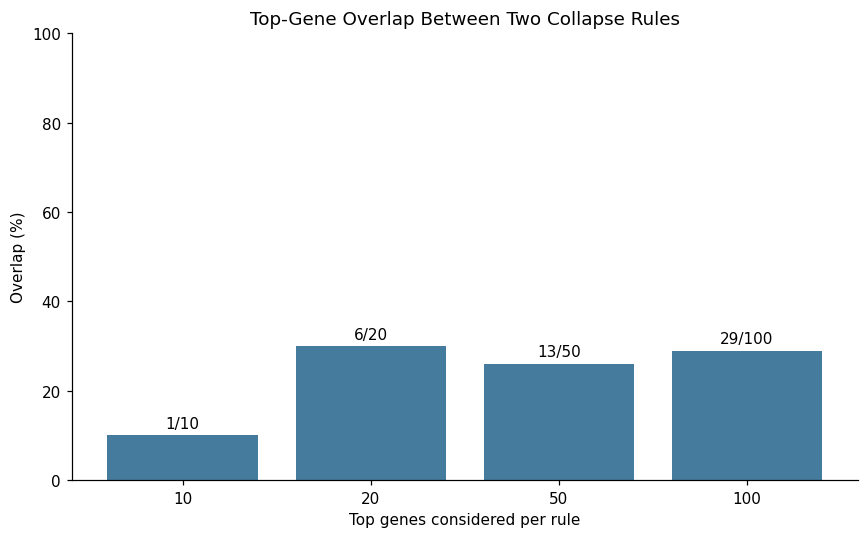

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    overlap_summary["top_n"].astype(str),
    overlap_summary["overlap_percent"],
    color="#457B9D",
)
ax.bar_label(
    bars,
    labels=[
        f"{count}/{top_n}"
        for count, top_n in zip(
            overlap_summary["overlap_count"],
            overlap_summary["top_n"],
            strict=True,
        )
    ],
    padding=3,
)
ax.set_title("Top-Gene Overlap Between Two Collapse Rules")
ax.set_xlabel("Top genes considered per rule")
ax.set_ylabel("Overlap (%)")
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gene_collapse_rule_overlap.png", dpi=180, bbox_inches="tight")
plt.show()

## Interpretation of the Sensitivity Check

Most gene symbols have probes that do not cross zero in opposite directions, but direction conflicts are common among multi-probe genes. The two collapse rules also produce substantially different top-ranked lists because one prioritizes statistical evidence and the other prioritizes effect magnitude.

Neither rule combines probe evidence or resolves transcript-specific behavior. Genes with conflicting probes, many mappings, or rule-dependent representatives require probe-level review before any gene-level interpretation. Adjusted p-values remain probe-level values and are not recalculated after collapsing.